# Detecting edges

## Basic setup

In [1]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

import cv2
import numpy as np
from matplotlib import pyplot as plt

ModuleNotFoundError: No module named 'cv2'

## Loading images

In [3]:
nazwy_plikow = [
    # "../out/image1.jpg",
    "../out/image2.jpg",
    "../out/image3.jpg",
    "../out/image4.jpg",
    "../out/image5.jpg"
]

images = []

for file_name in nazwy_plikow:
    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

## Basic constants and functions initialization

In [4]:
main_image = images[0]

def displayTwoImages(images_arr):
    fig.add_subplot(1, 2, 1)
    plt.imshow(images_arr[1])
    plt.axis('off')

    fig.add_subplot(1, 2, 2)
    plt.imshow(images_arr[1], cmap=plt.get_cmap('gray'))
    plt.axis('off')

## Displaying loaded images

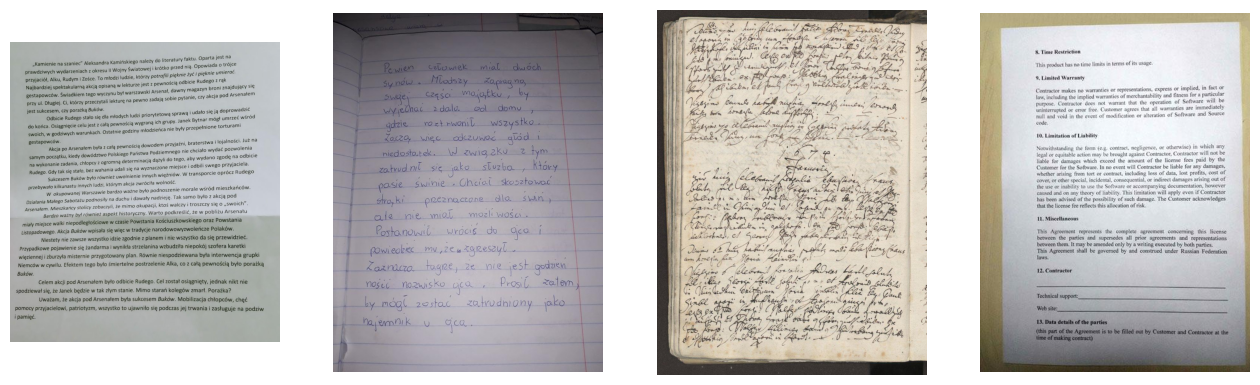

In [5]:
fig = plt.figure(figsize=(16, 8))

for i, img in enumerate(images):
    fig.add_subplot(1, len(images), i + 1)
    
    # plt.imshow(img)
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    plt.axis('off')
    
plt.show()

## HoughLines

In [ ]:
fig = plt.figure(figsize=(16, 8))

def modifyImage_HoughLines(image_cp):
    image_cp = cv2.cvtColor(image_cp, cv2.COLOR_BGR2GRAY)
    
    edges = cv2.Canny(image_cp, 200, 200, apertureSize=3)

    return edges
    
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 100,
                          30, 0, 0, 0, np.pi)

    # print(lines)
    print(f"count of lines: {len(lines)}")
    
    for rho, theta in lines[:,0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(image_cp, (x1,y1), (x2,y2), (255,0,255), 2)
    
    return image_cp

img = images[1]
fig.add_subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')

new_img = modifyImage_HoughLines(img)
fig.add_subplot(1, 2, 2)
plt.imshow(new_img, cmap=plt.get_cmap('gray'))
plt.axis('off')

plt.show()